In this notebook I am prototyping how to load experiment behavioral metadata from chectnut outputs and into a datastructure that plays nice with nilearn. We then use nilearns build in functionality to construct a design matrix and plot it. 

Approach: 
1) Load timestamps of scans
2) Load and parse task log file
3) Use timestamps of scans to set timestamps of stimulus onsets
4) Convert into something importable to nilearn
5) Use nilearns build in functionality to construct a design matrix and plot it.



Resources:

**I/O**
https://nilearn.github.io/dev/manipulating_images/input_output.html#extracting-data

**Computing ROIs:** 
https://nilearn.github.io/dev/auto_examples/06_manipulating_images/plot_roi_extraction.html#sphx-glr-auto-examples-06-manipulating-images-plot-roi-extraction-py

In [1]:
%load_ext autoreload
%autoreload 2
from nilearn import plotting


import nilearn as nl
import matplotlib.pyplot as plt
import numpy as np
import nibabel as nib
import os
import pandas as pd
import re

from nilearn.glm.first_level import make_first_level_design_matrix
from nilearn.plotting import plot_design_matrix


from pathlib import Path
from datetime import datetime, timedelta

from anise.io.load_matlab_dataset import load_data, load_selected_data




In [2]:
# and file handling
base_path=Path('/Users/taflalo/Data/UCLA/2024-04-19/UCLA-003/ses-2024-04-19/run-01')
sequence = 'seq-RF_5000000Hz_5a_3c_2rp_25Dmin_55Dmax_4el_TGC0ini_100end_1000Tdur_-1Gain_3AFE_200loops'


log_file_path = base_path / 'logs' / 'task_1.log'
sequence_data_path = base_path / 'acquisitions' / sequence 
raw_data_path = base_path / 'acquisitions' / sequence / 'raw_frame_data'
beamformed_path = base_path / 'acquisitions' / sequence / 'beamformed'
power_doppler_path = base_path / 'acquisitions' / sequence / 'power_doppler'
meta_data_path = base_path / 'acquisitions' / sequence / 'power_doppler'



print(f'log_file_path: {log_file_path}')
print(f'sequence_data_path: {sequence_data_path}')
print(f'raw_data_path: {raw_data_path}')
print(f'beamformed_path: {beamformed_path}')
print(f'power_doppler_path: {power_doppler_path}')
print(f'meta_data_path: {meta_data_path}')



log_file_path: /Users/taflalo/Data/UCLA/2024-04-19/UCLA-003/ses-2024-04-19/run-01/logs/task_1.log
sequence_data_path: /Users/taflalo/Data/UCLA/2024-04-19/UCLA-003/ses-2024-04-19/run-01/acquisitions/seq-RF_5000000Hz_5a_3c_2rp_25Dmin_55Dmax_4el_TGC0ini_100end_1000Tdur_-1Gain_3AFE_200loops
raw_data_path: /Users/taflalo/Data/UCLA/2024-04-19/UCLA-003/ses-2024-04-19/run-01/acquisitions/seq-RF_5000000Hz_5a_3c_2rp_25Dmin_55Dmax_4el_TGC0ini_100end_1000Tdur_-1Gain_3AFE_200loops/raw_frame_data
beamformed_path: /Users/taflalo/Data/UCLA/2024-04-19/UCLA-003/ses-2024-04-19/run-01/acquisitions/seq-RF_5000000Hz_5a_3c_2rp_25Dmin_55Dmax_4el_TGC0ini_100end_1000Tdur_-1Gain_3AFE_200loops/beamformed
power_doppler_path: /Users/taflalo/Data/UCLA/2024-04-19/UCLA-003/ses-2024-04-19/run-01/acquisitions/seq-RF_5000000Hz_5a_3c_2rp_25Dmin_55Dmax_4el_TGC0ini_100end_1000Tdur_-1Gain_3AFE_200loops/power_doppler
meta_data_path: /Users/taflalo/Data/UCLA/2024-04-19/UCLA-003/ses-2024-04-19/run-01/acquisitions/seq-RF_5000000

In [3]:
# If beamforming and power doppler have not been performed, perform them using the following commands in your terminal (make sure mangrove is activated!)
# Command to execute the mangrove raw data to beamformed conversion
beamform_command =  f'python -m mangrove.io.convert.mangrove_raw_data_to_beamformed input_mode=experiments_root_folder input_mode.experiments_root_folder="{sequence_data_path}"'
power_doppler_command =  f'python -m mangrove.io.convert.beamformed_to_doppler input_mode=experiments_root_folder input_mode.experiments_root_folder="{sequence_data_path}"'

print(beamform_command)
print(power_doppler_command)



python -m mangrove.io.convert.mangrove_raw_data_to_beamformed input_mode=experiments_root_folder input_mode.experiments_root_folder="/Users/taflalo/Data/UCLA/2024-04-19/UCLA-003/ses-2024-04-19/run-01/acquisitions/seq-RF_5000000Hz_5a_3c_2rp_25Dmin_55Dmax_4el_TGC0ini_100end_1000Tdur_-1Gain_3AFE_200loops"
python -m mangrove.io.convert.beamformed_to_doppler input_mode=experiments_root_folder input_mode.experiments_root_folder="/Users/taflalo/Data/UCLA/2024-04-19/UCLA-003/ses-2024-04-19/run-01/acquisitions/seq-RF_5000000Hz_5a_3c_2rp_25Dmin_55Dmax_4el_TGC0ini_100end_1000Tdur_-1Gain_3AFE_200loops"


In [4]:

# Function to read h5 filenames and extract datetime
def load_fUSi_info(directory):
    # List all h5 files in the directory
    filenames = [f for f in os.listdir(directory) if f.endswith('.h5')]
    
    # Extract datetime from filenames and store data
    data = []
    for filename in filenames:
        timestamp = re.search(r'\d{4}-\d{2}-\d{2}T\d{2}-\d{2}-\d{2}-\d{6}', filename)
        if timestamp:
            data.append({
                'Filename': filename,
                'Timestamp': pd.to_datetime(timestamp.group(0).replace('-', ':'), format='%Y:%m:%dT%H:%M:%S:%f')
            })
    

    power_doppler_df=pd.DataFrame(data)
    # Sort the DataFrame by the 'Timestamp' column
    power_doppler_df = power_doppler_df.sort_values(by='Timestamp')

    # Calculate the relative times since the first event
    power_doppler_df['Experiment Time'] = (power_doppler_df['Timestamp'] - power_doppler_df['Timestamp'].iloc[0]).dt.total_seconds()

    #  format excluding the date and keeping the first digit of milliseconds
    power_doppler_df['Readable Timestamp'] = power_doppler_df['Timestamp'].dt.strftime('%H:%M:%S.%f').str[:-5]

    return power_doppler_df

# Load information about the timing of the fUSi data
power_doppler_df = load_fUSi_info(power_doppler_path)
print(power_doppler_df)


                                             Filename  \
27  ensemble_2024-04-19T11-24-17-756484-pixel_size...   
44  ensemble_2024-04-19T11-24-21-283704-pixel_size...   
31  ensemble_2024-04-19T11-24-24-779761-pixel_size...   
38  ensemble_2024-04-19T11-24-28-352267-pixel_size...   
18  ensemble_2024-04-19T11-24-31-870953-pixel_size...   
..                                                ...   
42  ensemble_2024-04-19T11-27-36-100637-pixel_size...   
30  ensemble_2024-04-19T11-27-39-642399-pixel_size...   
13  ensemble_2024-04-19T11-27-43-167753-pixel_size...   
24  ensemble_2024-04-19T11-27-46-712409-pixel_size...   
36  ensemble_2024-04-19T11-27-50-263769-pixel_size...   

                    Timestamp  Experiment Time Readable Timestamp  
27 2024-04-19 11:24:17.756484         0.000000         11:24:17.7  
44 2024-04-19 11:24:21.283704         3.527220         11:24:21.2  
31 2024-04-19 11:24:24.779761         7.023277         11:24:24.7  
38 2024-04-19 11:24:28.352267        10.595

In [6]:
import pandas as pd
import re

# Function to parse task log file 
def process_task_log(log_file_path,timeoffset=0):

    # Read the entire log file
    with open(log_file_path, 'r') as file:
        lines = file.readlines()
    
    #  parse lines
    data = []
    for line in lines:
        # Extract timestamp and event description
        timestamp = re.search(r'\d{4}-\d{2}-\d{2}T\d{2}:\d{2}:\d{2}\.\d{6}\+\d{2}:\d{2}', line)
        # timestamp = re.search(r'\d{4}-\d{2}-\d{2}T\d{2}:\d{2}:\d{2}\.\d{6}\+\d{2}:\d{2}', line)
        event = re.search(r'Stimulus (on|off)', line)
        if timestamp and event:
            data.append({
                'Timestamp': pd.to_datetime(timestamp.group(0)).tz_localize(None)- timedelta(hours=timeoffset),
                # 'Timestamp': pd.to_datetime(timestamp.group(0)),
                'Event': event.group(0)
            })

    behavior_df=pd.DataFrame(data)     
    # Calculate the relative times since the first event
    behavior_df['Experiment Time'] = (behavior_df['Timestamp'] - power_doppler_df['Timestamp'].iloc[0]).dt.total_seconds()      
    #  format excluding the date and keeping the first digit of milliseconds
    behavior_df['Readable Timestamp'] = behavior_df['Timestamp'].dt.strftime('%H:%M:%S.%f').str[:-5]
    return behavior_df


# Parse the log file to extract relevant data
behavior_df = process_task_log(log_file_path,7)

# Display the resulting DataFrame
print(behavior_df)


                   Timestamp         Event  Experiment Time Readable Timestamp
0 2024-04-19 11:24:35.479655   Stimulus on        17.723171         11:24:35.4
1 2024-04-19 11:24:55.504066  Stimulus off        37.747582         11:24:55.5
2 2024-04-19 11:25:31.302670   Stimulus on        73.546186         11:25:31.3
3 2024-04-19 11:25:51.390244  Stimulus off        93.633760         11:25:51.3
4 2024-04-19 11:26:28.691004   Stimulus on       130.934520         11:26:28.6
5 2024-04-19 11:26:48.694081  Stimulus off       150.937597         11:26:48.6
6 2024-04-19 11:27:25.765365   Stimulus on       188.008881         11:27:25.7
7 2024-04-19 11:27:45.868250  Stimulus off       208.111766         11:27:45.8


Convert the pandas data structure into something importable to nilearn


In [ ]:
def calculate_stimulus_events(behavior_df):
    # Extract trial durations
    on_times = behavior_df[behavior_df['Event'] == 'Stimulus on']['Experiment Time'].reset_index(drop=True)
    off_times = behavior_df[behavior_df['Event'] == 'Stimulus off']['Experiment Time'].reset_index(drop=True)

    # Calculating the duration for which the stimulus was on
    if len(on_times) == len(off_times):
        stimulus_durations = off_times - on_times
        print("Stimulus durations (s):")
        print(stimulus_durations)
    else:
        print("Mismatch in 'on' and 'off' events count.")
        return None

    # Extract conditions and onset times
    stimulus_df = behavior_df[behavior_df['Event'] == 'Stimulus on']
    conditions = stimulus_df['Event'].tolist()
    onsets = stimulus_df['Experiment Time'].tolist()

    events = pd.DataFrame(
        {"trial_type": conditions, "onset": onsets, "duration": stimulus_durations}
    )

    return events

# Use the function to calculate events
events = calculate_stimulus_events(behavior_df)
print(events)


Stimulus durations (s):
0    20.024411
1    20.087574
2    20.003077
3    20.102885
Name: Relative Time (s), dtype: float64
    trial_type       onset   duration
0  Stimulus on   17.723171  20.024411
1  Stimulus on   73.546186  20.087574
2  Stimulus on  130.934520  20.003077
3  Stimulus on  188.008881  20.102885


In [ ]:
from nilearn.glm.first_level import make_first_level_design_matrix
import numpy as np
hrf_model = "glover"
X1 = make_first_level_design_matrix(
    power_doppler_df['Experiment Time'] ,
    events,
    drift_model="polynomial",
    drift_order=3,
    hrf_model=hrf_model,
)

/Users/taflalo/miniconda3/envs/Anise/lib/python3.9/site-packages/nilearn/glm/first_level/hemodynamic_models.py:403: UserWarning: Some stimulus onsets are earlier than 131.710255 in the experiment and are thus not considered in the model.
  warnings.warn(


/var/folders/gk/zbxjhf5j6h7bvyv252qq64s40000gn/T/ipykernel_32127/2011876207.py:9: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


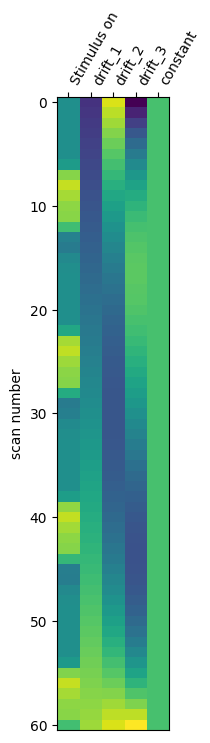

In [ ]:

# fig, ax = plt.subplots(figsize=(10, 6), nrows=1, ncols=1)

plot_design_matrix(X1)
# ax.set_title("FIR design matrix", fontsize=12)
fig.show()